In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("통합 데이터 전처리 파이프라인 구동 시작...")

# ==========================================
# 1. 데이터 로드 및 환율 통일
# ==========================================
try:
    df_india = pd.read_csv('Clean_Dataset.csv')
    df_bangla = pd.read_csv('Flight_Price_Dataset_of_Bangladesh.csv')
except FileNotFoundError as e:
    print(f"\n[경로 오류] 파일을 찾을 수 없습니다: {e}")
    raise

# [환율 통일] 1 BDT = 0.76 INR
EXCHANGE_RATE = 0.76
df_bangla['Total Fare (BDT)'] = df_bangla['Total Fare (BDT)'] * EXCHANGE_RATE

# ==========================================
# 2. 파생 변수 생성 및 컬럼명 통일 (Merge 준비)
# ==========================================
# [인도 데이터]
df_india.drop(columns=['Unnamed: 0', 'flight'], inplace=True, errors='ignore')
df_india['route'] = df_india['source_city'] + "_" + df_india['destination_city']
df_india.drop(columns=['source_city', 'destination_city'], inplace=True)
df_india['country'] = 'India'

# [방글라데시 데이터]
cols_to_drop = ['Source Name', 'Destination Name', 'Departure Date & Time',
                'Arrival Date & Time', 'Base Fare (BDT)', 'Tax & Surcharge (BDT)']
df_bangla.drop(columns=cols_to_drop, inplace=True, errors='ignore')
df_bangla['route'] = df_bangla['Source'] + "_" + df_bangla['Destination']
df_bangla.drop(columns=['Source', 'Destination'], inplace=True)
df_bangla['country'] = 'Bangladesh'

# 컬럼명 통일
rename_dict = {
    'Airline': 'airline', 'Stopovers': 'stops', 'Class': 'class',
    'Duration (hrs)': 'duration', 'Days Before Departure': 'days_left',
    'Total Fare (BDT)': 'price'
}
df_bangla.rename(columns=rename_dict, inplace=True)

# ==========================================
# 3. 공통 컬럼만 추출하여 병합 (데이터 증발 방지)
# ==========================================
# 두 데이터셋에 모두 존재하는 컬럼만 찾아서 합칩니다.
common_cols = list(set(df_india.columns).intersection(set(df_bangla.columns)))
df_combined = pd.concat([df_india[common_cols], df_bangla[common_cols]], ignore_index=True)

print(f"\n[병합 직후 행 수]: {len(df_combined)}행")

# ==========================================
# 4. 조건 필터링 (First Class 제외 및 Null 제거)
# ==========================================
# class 텍스트의 띄어쓰기를 없애고 소문자로 확실하게 변환
df_combined['class'] = df_combined['class'].astype(str).str.strip().str.lower()
df_combined = df_combined[df_combined['class'].isin(['economy', 'business'])]

# 1차 Null 값 전체 제거
df_combined.dropna(inplace=True)
print(f"[1차 Null & First Class 제거 후 행 수]: {len(df_combined)}행")

# ==========================================
# 5. 공통 Feature Engineering (피드백 ② 반영)
# ==========================================
bins = [-1, 7, 21, float('inf')]

# [수정] cat.codes 대신 astype(int)를 사용하여 빈 구간으로 인한 인덱스 꼬임 방지
df_combined['booking_period'] = pd.cut(
    df_combined['days_left'], bins=bins, labels=[0, 1, 2]
).astype(int)

# 경유 횟수 매핑 강화 (띄어쓰기 제거나 non-stop 등 예외처리 추가)
def map_stops(x):
    x = str(x).lower().strip()
    if 'zero' in x or 'direct' in x or 'non' in x or '0' in x: return 0
    elif 'one' in x or '1' in x: return 1
    elif 'two' in x or '2' in x: return 2
    elif 'three' in x or '3' in x: return 3
    return np.nan

df_combined['stops'] = df_combined['stops'].apply(map_stops)

# 2차 Null 제거 (매핑 불가 값)
df_combined.dropna(inplace=True)
print(f"[2차 Stops 결측치 제거 후 최종 행 수]: {len(df_combined)}행")

# 데이터가 비어버렸는지 최종 검사
if len(df_combined) == 0:
    raise ValueError("에러: 전처리 과정에서 모든 데이터가 삭제되었습니다. 데이터를 다시 확인해주세요.")

df_combined['stops'] = df_combined['stops'].astype(int)
df_combined['price'] = np.log1p(df_combined['price'])

# ==========================================
# 6. 인코딩, 데이터 분할 및 스케일링 함수 (피드백 ① 반영)
# ==========================================
def prep_for_modeling(df, target_col='price'):
    df_encoded = pd.get_dummies(df, drop_first=True)
    X = df_encoded.drop(columns=[target_col])
    y = df_encoded[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # [수정] 실전 배포 대비: X_test의 컬럼을 X_train에 맞춤 (없는 컬럼은 0으로 채움)
    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(
        scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index
    )
    X_test_scaled = pd.DataFrame(
        scaler.transform(X_test), columns=X_test.columns, index=X_test.index
    )

    return X_train_scaled, X_test_scaled, y_train, y_test

X_tr, X_te, y_tr, y_te = prep_for_modeling(df_combined)

print("\n통합 데이터 파이프라인 처리 완료!")
print(f"[Combined Data] Train shape: {X_tr.shape}, Test shape: {X_te.shape}")

# ==========================================
# 7. CSV 파일 자동 저장
# ==========================================
train_df = pd.concat([X_tr, y_tr], axis=1)
train_df.to_csv('Combined_Flights_train.csv', index=False, encoding='utf-8-sig')

test_df = pd.concat([X_te, y_te], axis=1)
test_df.to_csv('Combined_Flights_test.csv', index=False, encoding='utf-8-sig')

print("\n총 2개의 CSV 파일이 성공적으로 저장되었습니다.")

통합 데이터 전처리 파이프라인 구동 시작...

[병합 직후 행 수]: 357153행
[1차 Null & First Class 제거 후 행 수]: 338174행
[2차 Stops 결측치 제거 후 최종 행 수]: 338174행

통합 데이터 파이프라인 처리 완료!
[Combined Data] Train shape: (270539, 214), Test shape: (67635, 214)

총 2개의 CSV 파일이 성공적으로 저장되었습니다.


In [2]:
import os

file_path = 'Combined_Flights_train.csv'

if os.path.exists(file_path):
    size = os.path.getsize(file_path)
    print(f"파일 크기: {size} bytes")
    if size > 0:
        # 정상적으로 읽히는지 확인
        test_read = pd.read_csv(file_path, nrows=5)
        print("파일 상위 5행 로드 성공!")
        print(test_read)
    else:
        print("경고: 파일이 비어 있습니다 (0 bytes).")
else:
    print("파일이 존재하지 않습니다.")

파일 크기: 1238559108 bytes
파일 상위 5행 로드 성공!
   duration     stops  days_left  booking_period  route_BZL_CCU  \
0  0.172043  0.294352  -0.671583       -0.761099      -0.027199   
1 -0.650485  0.294352   0.708453        0.717990      -0.027199   
2 -0.402914  0.294352  -0.491578       -0.761099      -0.027199   
3 -0.143169  0.294352  -0.431577       -0.761099      -0.027199   
4  0.567073  2.499231   0.348444        0.717990      -0.027199   

   route_BZL_CGP  route_BZL_CXB  route_BZL_DAC  route_BZL_DEL  route_BZL_DOH  \
0      -0.027403      -0.027063      -0.025075      -0.028004      -0.026719   
1      -0.027403      -0.027063      -0.025075      -0.028004      -0.026719   
2      -0.027403      -0.027063      -0.025075      -0.028004      -0.026719   
3      -0.027403      -0.027063      -0.025075      -0.028004      -0.026719   
4      -0.027403      -0.027063      -0.025075      -0.028004      -0.026719   

   ...  airline_Qatar Airways  airline_Saudia  airline_Singapore Airlines  \

In [3]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# 데이터 로드
train_df = pd.read_csv('Combined_Flights_train.csv')
test_df  = pd.read_csv('Combined_Flights_test.csv')

TARGET = 'price'
X_train, y_train = train_df.drop(columns=[TARGET]), train_df[TARGET]
X_test,  y_test  = test_df.drop(columns=[TARGET]),  test_df[TARGET]
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# 평가 함수
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    y_pred_tr = model.predict(X_tr)
    y_pred_te = model.predict(X_te)

    r2_tr   = r2_score(y_tr, y_pred_tr)
    r2_te   = r2_score(y_te, y_pred_te)
    rmse_te = np.sqrt(mean_squared_error(y_te, y_pred_te))
    mae_te  = mean_absolute_error(y_te, y_pred_te)
    rmse_inr = np.sqrt(mean_squared_error(np.expm1(y_te), np.expm1(y_pred_te)))
    mae_inr  = mean_absolute_error(np.expm1(y_te), np.expm1(y_pred_te))

    print(f"\n[{name}]")
    print(f"  Train R²: {r2_tr:.4f} | Test R²: {r2_te:.4f}")
    print(f"  Test RMSE(log): {rmse_te:.4f} | Test MAE(log): {mae_te:.4f}")
    print(f"  Test RMSE(INR): {rmse_inr:.1f} | Test MAE(INR): {mae_inr:.1f}")

    return {'model': name, 'train_r2': r2_tr, 'test_r2': r2_te,
            'test_rmse_log': rmse_te, 'test_mae_log': mae_te,
            'test_rmse_inr': rmse_inr, 'test_mae_inr': mae_inr}

# GridSearchCV
ALPHA_GRID = [0.001, 0.01, 0.1, 0.5, 1, 5, 10, 50, 100, 500, 1000]
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Ridge
print("[ Ridge 하이퍼파라미터 탐색 중... ]")
ridge_gs = GridSearchCV(Ridge(), {'alpha': ALPHA_GRID}, cv=cv,
                        scoring='neg_root_mean_squared_error', n_jobs=-1)
ridge_gs.fit(X_train, y_train)
best_alpha_ridge = ridge_gs.best_params_['alpha']
print(f"  최적 alpha: {best_alpha_ridge} | CV RMSE: {-ridge_gs.best_score_:.4f}")
best_ridge = Ridge(alpha=best_alpha_ridge).fit(X_train, y_train)
ridge_result = evaluate_model(f"Ridge (alpha={best_alpha_ridge})",
                              best_ridge, X_train, y_train, X_test, y_test)

# Lasso
print("\n[ Lasso 하이퍼파라미터 탐색 중... ]")
lasso_gs = GridSearchCV(Lasso(max_iter=10000), {'alpha': ALPHA_GRID}, cv=cv,
                        scoring='neg_root_mean_squared_error', n_jobs=-1)
lasso_gs.fit(X_train, y_train)
best_alpha_lasso = lasso_gs.best_params_['alpha']
print(f"  최적 alpha: {best_alpha_lasso} | CV RMSE: {-lasso_gs.best_score_:.4f}")
best_lasso = Lasso(alpha=best_alpha_lasso, max_iter=10000).fit(X_train, y_train)
n_zero = np.sum(best_lasso.coef_ == 0)
print(f"  피처 희소성: {n_zero}/{len(best_lasso.coef_)}개 계수가 0 ({n_zero/len(best_lasso.coef_)*100:.1f}% 제거)")
lasso_result = evaluate_model(f"Lasso (alpha={best_alpha_lasso})",
                              best_lasso, X_train, y_train, X_test, y_test)

# 비교 요약
print("\n" + "=" * 60)
print("  최종 모델 비교 요약")
print("=" * 60)
summary = pd.DataFrame([ridge_result, lasso_result]).set_index('model')
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
print(summary.T.to_string())

[ Ridge 하이퍼파라미터 탐색 중... ]
  최적 alpha: 10 | CV RMSE: 0.4026

[Ridge (alpha=10)]
  Train R²: 0.8775 | Test R²: 0.8791
  Test RMSE(log): 0.3994 | Test MAE(log): 0.3030
  Test RMSE(INR): 14510.9 | Test MAE(INR): 6706.6

[ Lasso 하이퍼파라미터 탐색 중... ]
  최적 alpha: 0.001 | CV RMSE: 0.4027
  피처 희소성: 39/214개 계수가 0 (18.2% 제거)

[Lasso (alpha=0.001)]
  Train R²: 0.8773 | Test R²: 0.8789
  Test RMSE(log): 0.3996 | Test MAE(log): 0.3033
  Test RMSE(INR): 14106.1 | Test MAE(INR): 6642.8

  최종 모델 비교 요약
model          Ridge (alpha=10)  Lasso (alpha=0.001)
train_r2                 0.8775               0.8773
test_r2                  0.8791               0.8789
test_rmse_log            0.3994               0.3996
test_mae_log             0.3030               0.3033
test_rmse_inr        14510.8750           14106.1275
test_mae_inr          6706.5789            6642.8257


In [8]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import uniform, randint
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. 데이터 로드
# ==========================================
print("=" * 60)
print("XGBoost 모델 하이퍼파라미터 최적화 (RandomizedSearch)")
print("=" * 60)

train_df = pd.read_csv('Combined_Flights_train.csv')
test_df  = pd.read_csv('Combined_Flights_test.csv')
TARGET   = 'price'

X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]
X_test  = test_df.drop(columns=[TARGET]).reindex(columns=X_train.columns, fill_value=0)
y_test  = test_df[TARGET]

print(f"  Train: {X_train.shape}, Test: {X_test.shape}\n")

# ==========================================
# 2. 평가 함수
# ==========================================
def evaluate(name, model):
    y_tr_pred = model.predict(X_train)
    y_te_pred = model.predict(X_test)

    train_r2   = r2_score(y_train, y_tr_pred)
    test_r2    = r2_score(y_test,  y_te_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_tr_pred))
    test_rmse  = np.sqrt(mean_squared_error(y_test,  y_te_pred))
    train_mae  = mean_absolute_error(y_train, y_tr_pred)
    test_mae   = mean_absolute_error(y_test,  y_te_pred)

    tr_orig, te_orig           = np.expm1(y_train), np.expm1(y_test)
    tr_pred_orig, te_pred_orig = np.expm1(y_tr_pred), np.expm1(y_te_pred)
    train_rmse_inr = np.sqrt(mean_squared_error(tr_orig, tr_pred_orig))
    test_rmse_inr  = np.sqrt(mean_squared_error(te_orig, te_pred_orig))
    train_mae_inr  = mean_absolute_error(tr_orig, tr_pred_orig)
    test_mae_inr   = mean_absolute_error(te_orig, te_pred_orig)

    print(f"\n{'─'*55}")
    print(f"  {name}")
    print(f"{'─'*55}")
    print(f"  {'지표':<22} {'Train':>12} {'Test':>12}")
    print(f"  {'─'*46}")
    print(f"  {'R² Score':<22} {train_r2:>12.4f} {test_r2:>12.4f}")
    print(f"  {'RMSE (log scale)':<22} {train_rmse:>12.4f} {test_rmse:>12.4f}")
    print(f"  {'MAE  (log scale)':<22} {train_mae:>12.4f} {test_mae:>12.4f}")
    print(f"  {'RMSE (INR)':<22} {train_rmse_inr:>12.1f} {test_rmse_inr:>12.1f}")
    print(f"  {'MAE  (INR)':<22} {train_mae_inr:>12.1f} {test_mae_inr:>12.1f}")

    gap = train_r2 - test_r2
    if gap > 0.05:
        flag = f"⚠️  과적합 의심 (R² 갭: {gap:.4f})"
    elif test_r2 > train_r2 + 0.01:
        flag = f"🔍 데이터 누수 또는 분할 불균형 의심 (역갭: {abs(gap):.4f})"
    elif test_r2 < 0.5:
        flag = f"⚠️  과소적합 의심 (Test R²: {test_r2:.4f})"
    else:
        flag = "✅  양호"
    print(f"\n  진단: {flag}")

# ==========================================
# 3. RandomizedSearchCV (전 파라미터 한 번에)
# ==========================================
param_dist = {
    'n_estimators':     randint(100, 300),
    'learning_rate':    uniform(0.01, 0.19),    # 0.01 ~ 0.20
    'max_depth':        randint(3, 7),           # 3 ~ 6
    'min_child_weight': randint(1, 6),           # 1 ~ 5
    'subsample':        uniform(0.7, 0.3),       # 0.7 ~ 1.0
    'colsample_bytree': uniform(0.7, 0.3),       # 0.7 ~ 1.0
    'reg_alpha':        uniform(0, 1),           # 0 ~ 1
    'reg_lambda':       uniform(0.5, 4.5),       # 0.5 ~ 5
    'gamma':            uniform(0, 1),           # 0 ~ 1
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

print("[ RandomizedSearchCV 탐색 중... (n_iter=30) ]")
rs = RandomizedSearchCV(
    XGBRegressor(random_state=42, tree_method='hist', verbosity=0),
    param_distributions=param_dist,
    n_iter=15,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
rs.fit(X_train, y_train)

print(f"\n  최적 CV RMSE : {-rs.best_score_:.4f}")
print("\n[ 최적 파라미터 ]")
skip = {'random_state', 'tree_method', 'verbosity'}
for k, v in rs.best_params_.items():
    if k not in skip:
        print(f"  {k:<22}: {v:.4f}" if isinstance(v, float) else f"  {k:<22}: {v}")

# ==========================================
# 4. 최종 모델 학습 및 평가
# ==========================================
best_xgb = XGBRegressor(random_state=42, tree_method='hist',
                         verbosity=0, **rs.best_params_)
best_xgb.fit(X_train, y_train)

p = rs.best_params_
evaluate(f"XGBoost (lr={p['learning_rate']:.3f}, "
         f"depth={p['max_depth']}, n_est={p['n_estimators']})",
         best_xgb)

# ==========================================
# 5. CV 안정성
# ==========================================
cv_scores = cross_val_score(best_xgb, X_train, y_train,
                             cv=cv, scoring='r2', n_jobs=-1)
print(f"\n  5-Fold CV R²: {[f'{s:.4f}' for s in cv_scores]}")
print(f"  평균: {cv_scores.mean():.4f}  |  표준편차: {cv_scores.std():.4f}")

# ==========================================
# 6. 피처 중요도 상위 15개
# ==========================================
print("\n\n" + "=" * 60)
print("  피처 중요도 상위 15개")
print("=" * 60)
imp_df = (pd.DataFrame({'feature':    X_train.columns,
                        'importance': best_xgb.feature_importances_})
          .sort_values('importance', ascending=False)
          .head(15)
          .assign(pct=lambda d: d['importance'] / d['importance'].sum() * 100))
print(imp_df.to_string(index=False, float_format='%.4f'))

print("\n모델링 완료.")

XGBoost 모델 하이퍼파라미터 최적화 (RandomizedSearch)
  Train: (270539, 214), Test: (67635, 214)

[ RandomizedSearchCV 탐색 중... (n_iter=30) ]
Fitting 5 folds for each of 15 candidates, totalling 75 fits

  최적 CV RMSE : 0.2574

[ 최적 파라미터 ]
  colsample_bytree      : 0.7550
  gamma                 : 0.3042
  learning_rate         : 0.1097
  max_depth             : 6
  min_child_weight      : 1
  n_estimators          : 148
  reg_alpha             : 0.5248
  reg_lambda            : 2.2994
  subsample             : 0.7140

───────────────────────────────────────────────────────
  XGBoost (lr=0.110, depth=6, n_est=148)
───────────────────────────────────────────────────────
  지표                            Train         Test
  ──────────────────────────────────────────────
  R² Score                     0.9511       0.9509
  RMSE (log scale)             0.2537       0.2546
  MAE  (log scale)             0.1790       0.1792
  RMSE (INR)                   8291.6       8414.5
  MAE  (INR)                   3

In [3]:
import pandas as pd
import numpy as np
from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import uniform, randint
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. 데이터 로드 및 컬럼 정제
# ==========================================
print("=" * 60)
print("LightGBM 모델 하이퍼파라미터 최적화 (RandomizedSearch)")
print("=" * 60)

train_df = pd.read_csv('Combined_Flights_train.csv')
test_df  = pd.read_csv('Combined_Flights_test.csv')
TARGET   = 'price'

# 공백 제거 및 중복 컬럼 처리 함수
def clean_columns(df):
    df.columns = df.columns.str.strip()
    df.columns = df.columns.str.replace(r'[,\[\]{}<>()\s]', '_', regex=True)
    df.columns = df.columns.str.replace(r'_+', '_', regex=True)
    df.columns = df.columns.str.strip('_')
    df = df.loc[:, ~df.columns.duplicated(keep='first')]
    return df
train_df = clean_columns(train_df)
test_df = clean_columns(test_df)

X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]
y_test  = test_df[TARGET]

# 테스트셋의 컬럼 구성을 학습셋과 완전히 동일하게 맞춤
# (학습셋에만 있는 컬럼은 0으로 채우고, 학습셋에 없는 컬럼은 버림)
X_test = test_df.reindex(columns=X_train.columns, fill_value=0)

# [중요] LightGBM은 특수문자나 중복에 민감하므로 최종 체크
print(f"  중복 컬럼 존재 여부: {X_train.columns.duplicated().any()}")
print(f"  Train shape: {X_train.shape}, Test shape: {X_test.shape}\n")

# ==========================================
# 2. 평가 함수
# ==========================================
def evaluate(name, model):
    y_tr_pred = model.predict(X_train)
    y_te_pred = model.predict(X_test)

    train_r2   = r2_score(y_train, y_tr_pred)
    test_r2    = r2_score(y_test,  y_te_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_tr_pred))
    test_rmse  = np.sqrt(mean_squared_error(y_test,  y_te_pred))
    train_mae  = mean_absolute_error(y_train, y_tr_pred)
    test_mae   = mean_absolute_error(y_test,  y_te_pred)

    tr_orig, te_orig           = np.expm1(y_train), np.expm1(y_test)
    tr_pred_orig, te_pred_orig = np.expm1(y_tr_pred), np.expm1(y_te_pred)
    train_rmse_inr = np.sqrt(mean_squared_error(tr_orig, tr_pred_orig))
    test_rmse_inr  = np.sqrt(mean_squared_error(te_orig, te_pred_orig))
    train_mae_inr  = mean_absolute_error(tr_orig, tr_pred_orig)
    test_mae_inr   = mean_absolute_error(te_orig, te_pred_orig)

    print(f"\n{'─'*55}")
    print(f"  {name}")
    print(f"{'─'*55}")
    print(f"  {'지표':<22} {'Train':>12} {'Test':>12}")
    print(f"  {'─'*46}")
    print(f"  {'R² Score':<22} {train_r2:>12.4f} {test_r2:>12.4f}")
    print(f"  {'RMSE (log scale)':<22} {train_rmse:>12.4f} {test_rmse:>12.4f}")
    print(f"  {'MAE  (log scale)':<22} {train_mae:>12.4f} {test_mae:>12.4f}")
    print(f"  {'RMSE (INR)':<22} {train_rmse_inr:>12.1f} {test_rmse_inr:>12.1f}")
    print(f"  {'MAE  (INR)':<22} {train_mae_inr:>12.1f} {test_mae_inr:>12.1f}")

    gap = train_r2 - test_r2
    if gap > 0.05:
        flag = f"⚠️  과적합 의심 (R² 갭: {gap:.4f})"
    elif test_r2 > train_r2 + 0.01:
        flag = f"🔍 데이터 누수 또는 분할 불균형 의심 (역갭: {abs(gap):.4f})"
    elif test_r2 < 0.5:
        flag = f"⚠️  과소적합 의심 (Test R²: {test_r2:.4f})"
    else:
        flag = "✅  양호"
    print(f"\n  진단: {flag}")

# ==========================================
# 3. RandomizedSearchCV
#    속도 최적화:
#    - n_iter: 30 → 15
#    - n_estimators: ~700 → ~300 (상한 축소)
#    - cv: 5-fold → 3-fold
#    - num_leaves 상한 축소
# ==========================================
param_dist = {
    'n_estimators':      randint(100, 300),    # 상한 700 → 300
    'learning_rate':     uniform(0.01, 0.19),
    'max_depth':         randint(3, 8),
    'num_leaves':        randint(20, 80),      # 상한 150 → 80
    'min_child_samples': randint(10, 100),
    'subsample':         uniform(0.6, 0.4),
    'colsample_bytree':  uniform(0.6, 0.4),
    'reg_alpha':         uniform(0, 1),
    'reg_lambda':        uniform(0.5, 4.5),
}

cv = KFold(n_splits=3, shuffle=True, random_state=42)   # 5-fold → 3-fold

print("[ RandomizedSearchCV 탐색 중... (n_iter=15, 3-fold) ]")
rs = RandomizedSearchCV(
    LGBMRegressor(random_state=42, verbosity=-1),
    param_distributions=param_dist,
    n_iter=15,                                 # 30 → 15
    cv=cv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

X_train = X_train.loc[:, ~X_train.columns.duplicated()]
X_test = X_test.loc[:, ~X_test.columns.duplicated()]
rs.fit(X_train, y_train)

print(f"\n  최적 CV RMSE : {-rs.best_score_:.4f}")
print("\n[ 최적 파라미터 ]")
for k, v in rs.best_params_.items():
    print(f"  {k:<22}: {v:.4f}" if isinstance(v, float) else f"  {k:<22}: {v}")

# ==========================================
# 4. 최종 모델 학습 및 평가
# ==========================================
best_lgb = LGBMRegressor(random_state=42, verbosity=-1, **rs.best_params_)
best_lgb.fit(X_train, y_train)

p = rs.best_params_
evaluate(f"LightGBM (lr={p['learning_rate']:.3f}, "
         f"leaves={p['num_leaves']}, n_est={p['n_estimators']})",
         best_lgb)

# ==========================================
# 5. CV 안정성
# ==========================================
cv_scores = cross_val_score(best_lgb, X_train, y_train,
                             cv=cv, scoring='r2', n_jobs=-1)
print(f"\n  3-Fold CV R²: {[f'{s:.4f}' for s in cv_scores]}")
print(f"  평균: {cv_scores.mean():.4f}  |  표준편차: {cv_scores.std():.4f}")

# ==========================================
# 6. 피처 중요도 상위 15개
# ==========================================
print("\n\n" + "=" * 60)
print("  피처 중요도 상위 15개")
print("=" * 60)
imp_df = (pd.DataFrame({'feature':    X_train.columns,
                        'importance': best_lgb.feature_importances_})
          .sort_values('importance', ascending=False)
          .head(15)
          .assign(pct=lambda d: d['importance'] / d['importance'].sum() * 100))
print(imp_df.to_string(index=False, float_format='%.4f'))

print("\n모델링 완료.")

LightGBM 모델 하이퍼파라미터 최적화 (RandomizedSearch)
  중복 컬럼 존재 여부: False
  Train shape: (270539, 213), Test shape: (67635, 213)

[ RandomizedSearchCV 탐색 중... (n_iter=15, 3-fold) ]
Fitting 3 folds for each of 15 candidates, totalling 45 fits

  최적 CV RMSE : 0.2532

[ 최적 파라미터 ]
  colsample_bytree      : 0.6832
  learning_rate         : 0.1179
  max_depth             : 7
  min_child_samples     : 72
  n_estimators          : 245
  num_leaves            : 45
  reg_alpha             : 0.4498
  reg_lambda            : 2.2782
  subsample             : 0.9707

───────────────────────────────────────────────────────
  LightGBM (lr=0.118, leaves=45, n_est=245)
───────────────────────────────────────────────────────
  지표                            Train         Test
  ──────────────────────────────────────────────
  R² Score                     0.9541       0.9540
  RMSE (log scale)             0.2457       0.2462
  MAE  (log scale)             0.1695       0.1698
  RMSE (INR)                   8193.8    

In [12]:
!pip install catboost

   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.8/100.2 MB 16.2 MB/s eta 0:00:07
   - -------------------------------------- 5.0/100.2 MB 18.6 MB/s eta 0:00:06
   ---- ----------------------------------- 10.5/100.2 MB 22.9 MB/s eta 0:00:04
   ------- -------------------------------- 17.8/100.2 MB 26.1 MB/s eta 0:00:04
   --------- ------------------------------ 24.1/100.2 MB 27.2 MB/s eta 0:00:03
   ------------ --------------------------- 32.5/100.2 MB 29.3 MB/s eta 0:00:03
   --------------- ------------------------ 38.0/100.2 MB 28.7 MB/s eta 0:00:03
   ----------------- ---------------------- 43.8/100.2 MB 28.6 MB/s eta 0:00:02
   -------------------- ------------------- 51.6/100.2 MB 29.5 MB/s eta 0:00:02
   ----------------------- ---------------- 59.2/100.2 MB 30.2 MB/s eta 0:00:02
   -------------------------- ------------- 67.4/100.2 MB 31.2 MB/s eta 0:00:02
   ----------------------------- ---------- 75.0/10

In [1]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import uniform, randint
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. 데이터 로드 및 컬럼 정제
# ==========================================
print("=" * 60)
print("CatBoost 모델 하이퍼파라미터 최적화 (RandomizedSearch)")
print("=" * 60)

train_df = pd.read_csv('Combined_Flights_train.csv')
test_df  = pd.read_csv('Combined_Flights_test.csv')
TARGET   = 'price'

def clean_columns(df):
    df.columns = df.columns.str.strip()
    df.columns = df.columns.str.replace(r'[,\[\]{}<>()\s]', '_', regex=True)
    df.columns = df.columns.str.replace(r'_+', '_', regex=True)
    df.columns = df.columns.str.strip('_')
    df = df.loc[:, ~df.columns.duplicated(keep='first')]
    return df

train_df = clean_columns(train_df)
test_df  = clean_columns(test_df)

X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]
y_test  = test_df[TARGET]
X_test  = test_df.reindex(columns=X_train.columns, fill_value=0)

print(f"  중복 컬럼 존재 여부: {X_train.columns.duplicated().any()}")
print(f"  Train shape: {X_train.shape}, Test shape: {X_test.shape}\n")

# ==========================================
# 2. 평가 함수
# ==========================================
def evaluate(name, model):
    y_tr_pred = model.predict(X_train)
    y_te_pred = model.predict(X_test)

    train_r2   = r2_score(y_train, y_tr_pred)
    test_r2    = r2_score(y_test,  y_te_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_tr_pred))
    test_rmse  = np.sqrt(mean_squared_error(y_test,  y_te_pred))
    train_mae  = mean_absolute_error(y_train, y_tr_pred)
    test_mae   = mean_absolute_error(y_test,  y_te_pred)

    tr_orig, te_orig           = np.expm1(y_train), np.expm1(y_test)
    tr_pred_orig, te_pred_orig = np.expm1(y_tr_pred), np.expm1(y_te_pred)
    train_rmse_inr = np.sqrt(mean_squared_error(tr_orig, tr_pred_orig))
    test_rmse_inr  = np.sqrt(mean_squared_error(te_orig, te_pred_orig))
    train_mae_inr  = mean_absolute_error(tr_orig, tr_pred_orig)
    test_mae_inr   = mean_absolute_error(te_orig, te_pred_orig)

    print(f"\n{'─'*55}")
    print(f"  {name}")
    print(f"{'─'*55}")
    print(f"  {'지표':<22} {'Train':>12} {'Test':>12}")
    print(f"  {'─'*46}")
    print(f"  {'R² Score':<22} {train_r2:>12.4f} {test_r2:>12.4f}")
    print(f"  {'RMSE (log scale)':<22} {train_rmse:>12.4f} {test_rmse:>12.4f}")
    print(f"  {'MAE  (log scale)':<22} {train_mae:>12.4f} {test_mae:>12.4f}")
    print(f"  {'RMSE (INR)':<22} {train_rmse_inr:>12.1f} {test_rmse_inr:>12.1f}")
    print(f"  {'MAE  (INR)':<22} {train_mae_inr:>12.1f} {test_mae_inr:>12.1f}")

    gap = train_r2 - test_r2
    if gap > 0.05:
        flag = f"⚠️  과적합 의심 (R² 갭: {gap:.4f})"
    elif test_r2 > train_r2 + 0.01:
        flag = f"🔍 데이터 누수 또는 분할 불균형 의심 (역갭: {abs(gap):.4f})"
    elif test_r2 < 0.5:
        flag = f"⚠️  과소적합 의심 (Test R²: {test_r2:.4f})"
    else:
        flag = "✅  양호"
    print(f"\n  진단: {flag}")

# ==========================================
# 3. RandomizedSearchCV
# ==========================================
param_dist = {
    'iterations':        randint(300, 1000),
    'learning_rate':     uniform(0.01, 0.19),
    'depth':             randint(4, 10),
    'l2_leaf_reg':       uniform(1, 9),
    'bagging_temperature': uniform(0, 1),
    'random_strength':   uniform(0, 1),
    'border_count':      randint(32, 255),
}

cv = KFold(n_splits=3, shuffle=True, random_state=42)

print("[ RandomizedSearchCV 탐색 중... (n_iter=15, 3-fold) ]")
rs = RandomizedSearchCV(
    CatBoostRegressor(loss_function='RMSE', random_seed=42, verbose=0),
    param_distributions=param_dist,
    n_iter=15,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
rs.fit(X_train, y_train)

print(f"\n  최적 CV RMSE : {-rs.best_score_:.4f}")
print("\n[ 최적 파라미터 ]")
for k, v in rs.best_params_.items():
    print(f"  {k:<22}: {v:.4f}" if isinstance(v, float) else f"  {k:<22}: {v}")

# ==========================================
# 4. 최종 모델 학습 및 평가
# ==========================================
best_params = {
    k: int(v) if isinstance(v, (np.integer,)) else
       float(v) if isinstance(v, (np.floating,)) else v
    for k, v in rs.best_params_.items()
}

best_cb = CatBoostRegressor(loss_function='RMSE', random_seed=42,
                             verbose=0, **rs.best_params_)
best_cb.fit(X_train, y_train)

p = rs.best_params_
evaluate(f"CatBoost (lr={p['learning_rate']:.3f}, "
         f"depth={p['depth']}, iter={p['iterations']})",
         best_cb)

# ==========================================
# 5. CV 안정성
# ==========================================
cv_scores = cross_val_score(best_cb, X_train, y_train,
                             cv=cv, scoring='r2', n_jobs=-1)
print(f"\n  3-Fold CV R²: {[f'{s:.4f}' for s in cv_scores]}")
print(f"  평균: {cv_scores.mean():.4f}  |  표준편차: {cv_scores.std():.4f}")

# ==========================================
# 6. 피처 중요도 상위 15개
# ==========================================
print("\n\n" + "=" * 60)
print("  피처 중요도 상위 15개")
print("=" * 60)
imp_df = (pd.DataFrame({'feature':    X_train.columns,
                        'importance': best_cb.feature_importances_})
          .sort_values('importance', ascending=False)
          .head(15)
          .assign(pct=lambda d: d['importance'] / d['importance'].sum() * 100))
print(imp_df.to_string(index=False, float_format='%.4f'))

print("\n모델링 완료.")

ModuleNotFoundError: No module named 'catboost'

In [6]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import itertools
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. 데이터 로드 및 컬럼 정제
# ==========================================
print("=" * 60)
print("CatBoost 모델 하이퍼파라미터 최적화 (Manual RandomSearch)")
print("=" * 60)

train_df = pd.read_csv('Combined_Flights_train.csv')
test_df  = pd.read_csv('Combined_Flights_test.csv')
TARGET   = 'price'

def clean_columns(df):
    df.columns = df.columns.str.strip()
    df.columns = df.columns.str.replace(r'[,\[\]{}<>()\s]', '_', regex=True)
    df.columns = df.columns.str.replace(r'_+', '_', regex=True)
    df.columns = df.columns.str.strip('_')
    df = df.loc[:, ~df.columns.duplicated(keep='first')]
    return df

train_df = clean_columns(train_df)
test_df  = clean_columns(test_df)

X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]
y_test  = test_df[TARGET]
X_test  = test_df.reindex(columns=X_train.columns, fill_value=0)

print(f"  중복 컬럼 존재 여부: {X_train.columns.duplicated().any()}")
print(f"  Train shape: {X_train.shape}, Test shape: {X_test.shape}\n")

# ==========================================
# 2. 평가 함수
# ==========================================
def evaluate(name, model):
    y_tr_pred = model.predict(X_train)
    y_te_pred = model.predict(X_test)

    train_r2   = r2_score(y_train, y_tr_pred)
    test_r2    = r2_score(y_test,  y_te_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_tr_pred))
    test_rmse  = np.sqrt(mean_squared_error(y_test,  y_te_pred))
    train_mae  = mean_absolute_error(y_train, y_tr_pred)
    test_mae   = mean_absolute_error(y_test,  y_te_pred)

    tr_orig, te_orig           = np.expm1(y_train), np.expm1(y_test)
    tr_pred_orig, te_pred_orig = np.expm1(y_tr_pred), np.expm1(y_te_pred)
    train_rmse_inr = np.sqrt(mean_squared_error(tr_orig, tr_pred_orig))
    test_rmse_inr  = np.sqrt(mean_squared_error(te_orig, te_pred_orig))
    train_mae_inr  = mean_absolute_error(tr_orig, tr_pred_orig)
    test_mae_inr   = mean_absolute_error(te_orig, te_pred_orig)

    print(f"\n{'─'*55}")
    print(f"  {name}")
    print(f"{'─'*55}")
    print(f"  {'지표':<22} {'Train':>12} {'Test':>12}")
    print(f"  {'─'*46}")
    print(f"  {'R² Score':<22} {train_r2:>12.4f} {test_r2:>12.4f}")
    print(f"  {'RMSE (log scale)':<22} {train_rmse:>12.4f} {test_rmse:>12.4f}")
    print(f"  {'MAE  (log scale)':<22} {train_mae:>12.4f} {test_mae:>12.4f}")
    print(f"  {'RMSE (INR)':<22} {train_rmse_inr:>12.1f} {test_rmse_inr:>12.1f}")
    print(f"  {'MAE  (INR)':<22} {train_mae_inr:>12.1f} {test_mae_inr:>12.1f}")

    gap = train_r2 - test_r2
    if gap > 0.05:
        flag = f"⚠️  과적합 의심 (R² 갭: {gap:.4f})"
    elif test_r2 > train_r2 + 0.01:
        flag = f"🔍 데이터 누수 또는 분할 불균형 의심 (역갭: {abs(gap):.4f})"
    elif test_r2 < 0.5:
        flag = f"⚠️  과소적합 의심 (Test R²: {test_r2:.4f})"
    else:
        flag = "✅  양호"
    print(f"\n  진단: {flag}")

# ==========================================
# 3. 수동 RandomizedSearch (15회)
# ==========================================
np.random.seed(42)
N_ITER = 15

param_samples = [
    {
        'iterations':          int(np.random.randint(300, 1000)),
        'learning_rate':       float(np.random.uniform(0.01, 0.20)),
        'depth':               int(np.random.randint(4, 10)),
        'l2_leaf_reg':         float(np.random.uniform(1, 10)),
        'bagging_temperature': float(np.random.uniform(0, 1)),
        'random_strength':     float(np.random.uniform(0, 1)),
        'border_count':        int(np.random.randint(32, 255)),
    }
    for _ in range(N_ITER)
]

cv = KFold(n_splits=3, shuffle=True, random_state=42)

print("[ 수동 RandomizedSearch 탐색 중... (n_iter=15, 3-fold) ]")
best_score, best_params = np.inf, None

for i, params in enumerate(param_samples):
    model = CatBoostRegressor(loss_function='RMSE', random_seed=42,
                               verbose=0, **params)
    fold_rmses = []
    for tr_idx, val_idx in cv.split(X_train):
        model.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
        pred = model.predict(X_train.iloc[val_idx])
        fold_rmses.append(np.sqrt(mean_squared_error(y_train.iloc[val_idx], pred)))
    cv_rmse = float(np.mean(fold_rmses))
    print(f"  [{i+1:02d}/{N_ITER}] CV RMSE: {cv_rmse:.4f} | params: {params}")
    if cv_rmse < best_score:
        best_score, best_params = cv_rmse, params

print(f"\n  최적 CV RMSE : {best_score:.4f}")
print("\n[ 최적 파라미터 ]")
for k, v in best_params.items():
    print(f"  {k:<22}: {v:.4f}" if isinstance(v, float) else f"  {k:<22}: {v}")

# ==========================================
# 4. 최종 모델 학습 및 평가
# ==========================================
best_cb = CatBoostRegressor(loss_function='RMSE', random_seed=42,
                             verbose=0, **best_params)
best_cb.fit(X_train, y_train)

p = best_params
evaluate(f"CatBoost (lr={p['learning_rate']:.3f}, "
         f"depth={p['depth']}, iter={p['iterations']})",
         best_cb)

# ==========================================
# 5. CV 안정성
# ==========================================
cv_scores = []
for tr_idx, val_idx in cv.split(X_train):
    best_cb.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
    pred = best_cb.predict(X_train.iloc[val_idx])
    cv_scores.append(r2_score(y_train.iloc[val_idx], pred))

# 전체 데이터로 재학습
best_cb.fit(X_train, y_train)

print(f"\n  3-Fold CV R²: {[f'{s:.4f}' for s in cv_scores]}")
print(f"  평균: {np.mean(cv_scores):.4f}  |  표준편차: {np.std(cv_scores):.4f}")

# ==========================================
# 6. 피처 중요도 상위 15개
# ==========================================
print("\n\n" + "=" * 60)
print("  피처 중요도 상위 15개")
print("=" * 60)
imp_df = (pd.DataFrame({'feature':    X_train.columns,
                        'importance': best_cb.feature_importances_})
          .sort_values('importance', ascending=False)
          .head(15)
          .assign(pct=lambda d: d['importance'] / d['importance'].sum() * 100))
print(imp_df.to_string(index=False, float_format='%.4f'))

print("\n모델링 완료.")

CatBoost 모델 하이퍼파라미터 최적화 (Manual RandomSearch)
  중복 컬럼 존재 여부: False
  Train shape: (270539, 213), Test shape: (67635, 213)

[ 수동 RandomizedSearch 탐색 중... (n_iter=15, 3-fold) ]
  [01/15] CV RMSE: 0.2507 | params: {'iterations': 402, 'learning_rate': 0.16134316750344424, 'depth': 6, 'l2_leaf_reg': 8.017219002454922, 'bagging_temperature': 0.596850157946487, 'random_strength': 0.44583275285359114, 'border_count': 246}
  [02/15] CV RMSE: 0.2476 | params: {'iterations': 630, 'learning_rate': 0.09725728947351475, 'depth': 8, 'l2_leaf_reg': 6.41003510568888, 'bagging_temperature': 0.7080725777960455, 'random_strength': 0.020584494295802447, 'border_count': 33}
  [03/15] CV RMSE: 0.2410 | params: {'iterations': 643, 'learning_rate': 0.16816410175208013, 'depth': 9, 'l2_leaf_reg': 1.007008892569129, 'bagging_temperature': 0.9922115592912175, 'random_strength': 0.6174815096277165, 'border_count': 89}
  [04/15] CV RMSE: 0.3524 | params: {'iterations': 321, 'learning_rate': 0.011342597991746308, 'd

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
import time
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("KNN 최종 모델 (Jupyter 최적화 버전)")
print("=" * 60)

# ==========================================
# 1. 데이터 로드
# ==========================================
t0 = time.time()

train_df = pd.read_csv('Combined_Flights_train.csv')
test_df  = pd.read_csv('Combined_Flights_test.csv')
TARGET   = 'price'

def clean_columns(df):
    df.columns = df.columns.str.strip()
    df.columns = df.columns.str.replace(r'[,\[\]{}<>()\s]', '_', regex=True)
    df.columns = df.columns.str.replace(r'_+', '_', regex=True)
    df.columns = df.columns.str.strip('_')
    df = df.loc[:, ~df.columns.duplicated(keep='first')]
    return df

train_df = clean_columns(train_df)
test_df  = clean_columns(test_df)

X_train_arr = train_df.drop(columns=[TARGET]).values.astype(np.float32)
y_train     = train_df[TARGET].values.astype(np.float32)
y_test      = test_df[TARGET].values.astype(np.float32)

test_cols   = train_df.drop(columns=[TARGET]).columns
X_test_arr  = test_df.reindex(columns=test_cols, fill_value=0).values.astype(np.float32)

print(f"  Train : {X_train_arr.shape}")
print(f"  Test  : {X_test_arr.shape}")
print(f"  로드 완료: {time.time()-t0:.1f}s\n")

# ==========================================
# 2. 훈련 참조 데이터 샘플링
#    10~50만 행 → 10만으로 줄여도 R² 거의 동일
#    더 빠르게 원하면 50_000으로 낮춰도 됨
# ==========================================
MAX_FIT = 100_000

n_train = len(X_train_arr)
if n_train > MAX_FIT:
    rng = np.random.default_rng(42)
    idx = rng.choice(n_train, size=MAX_FIT, replace=False)
    X_fit, y_fit = X_train_arr[idx], y_train[idx]
    print(f"  ⚡ 샘플링: {n_train:,} → {MAX_FIT:,}건")
else:
    X_fit, y_fit = X_train_arr, y_train
    print(f"  전체 사용: {n_train:,}건")

# ==========================================
# 3. 모델 학습
# ==========================================
K = 8
knn = KNeighborsRegressor(
    n_neighbors = K,
    weights     = 'distance',
    p           = 2,
    algorithm   = 'ball_tree',  # 10~50개 피처엔 ball_tree가 최적
    leaf_size   = 40,
    n_jobs      = -1            # CPU 전체 코어 사용
)

print("\n  [1/3] 모델 학습...")
t1 = time.time()
knn.fit(X_fit, y_fit)
print(f"        완료: {time.time()-t1:.1f}s")

# ==========================================
# 4. 배치 예측 (메모리 절약 + 진행 상황 표시)
# ==========================================
def batch_predict(model, X, batch_size=8_000, label=""):
    n = len(X)
    preds = np.empty(n, dtype=np.float32)
    for i in range(0, n, batch_size):
        end = min(i + batch_size, n)
        preds[i:end] = model.predict(X[i:end])
        # 진행률 표시 (매 10배치마다)
        if (i // batch_size) % 10 == 0:
            print(f"        {label} {end:,}/{n:,} ({100*end/n:.0f}%)", end='\r')
    print()
    return preds

# Train 평가는 2만 샘플로 (전체 predict는 불필요)
EVAL_N = 20_000
rng2   = np.random.default_rng(0)
ev_idx = rng2.choice(len(X_train_arr), size=min(EVAL_N, len(X_train_arr)), replace=False)

print("\n  [2/3] Train 평가 (샘플 2만)...")
t2 = time.time()
y_tr_pred = batch_predict(knn, X_train_arr[ev_idx], label="Train")
y_tr_true = y_train[ev_idx]
print(f"        완료: {time.time()-t2:.1f}s")

print("\n  [3/3] Test 예측...")
t3 = time.time()
y_te_pred = batch_predict(knn, X_test_arr, label="Test ")
print(f"        완료: {time.time()-t3:.1f}s")

# ==========================================
# 5. 평가 출력
# ==========================================
def print_metrics(y_tr, y_te, y_tr_pred, y_te_pred):
    def metrics(y, yp):
        return (r2_score(y, yp),
                np.sqrt(mean_squared_error(y, yp)),
                mean_absolute_error(y, yp))

    tr_r2, tr_rmse, tr_mae = metrics(y_tr, y_tr_pred)
    te_r2, te_rmse, te_mae = metrics(y_te, y_te_pred)

    # 원래 스케일 (expm1 역변환)
    tr_rmse_inr = np.sqrt(mean_squared_error(np.expm1(y_tr), np.expm1(y_tr_pred)))
    te_rmse_inr = np.sqrt(mean_squared_error(np.expm1(y_te), np.expm1(y_te_pred)))
    tr_mae_inr  = mean_absolute_error(np.expm1(y_tr), np.expm1(y_tr_pred))
    te_mae_inr  = mean_absolute_error(np.expm1(y_te), np.expm1(y_te_pred))

    print(f"\n{'─'*55}")
    print(f"  KNN  k={K}, weights=distance, p=2")
    print(f"{'─'*55}")
    print(f"  {'지표':<22} {'Train':>12} {'Test':>12}")
    print(f"  {'─'*46}")
    print(f"  {'R² Score':<22} {tr_r2:>12.4f} {te_r2:>12.4f}")
    print(f"  {'RMSE (log)':<22} {tr_rmse:>12.4f} {te_rmse:>12.4f}")
    print(f"  {'MAE  (log)':<22} {tr_mae:>12.4f} {te_mae:>12.4f}")
    print(f"  {'RMSE (INR)':<22} {tr_rmse_inr:>12.1f} {te_rmse_inr:>12.1f}")
    print(f"  {'MAE  (INR)':<22} {tr_mae_inr:>12.1f} {te_mae_inr:>12.1f}")

    gap = tr_r2 - te_r2
    if   gap > 0.05:              diag = f"⚠️  과적합 의심 (갭 {gap:.4f})"
    elif te_r2 > tr_r2 + 0.01:   diag = f"🔍 데이터 누수 의심"
    elif te_r2 < 0.5:             diag = f"⚠️  과소적합 (Test R² {te_r2:.4f})"
    else:                         diag = "✅  양호"
    print(f"\n  진단: {diag}")

print_metrics(y_tr_true, y_test, y_tr_pred, y_te_pred)

# ==========================================
# 6. CV (샘플 5,000 × 3-Fold)
# ==========================================
print(f"\n{'─'*55}")
print("  CV 안정성 (5,000건 × 3-Fold)")
print(f"{'─'*55}")

rng3 = np.random.default_rng(42)
ci   = rng3.choice(len(X_fit), size=min(5_000, len(X_fit)), replace=False)
Xc, yc = X_fit[ci], y_fit[ci]

scores = []
for fold, (tr_i, val_i) in enumerate(KFold(3, shuffle=True, random_state=42).split(Xc), 1):
    m = KNeighborsRegressor(n_neighbors=K, weights='distance', p=2,
                             algorithm='ball_tree', n_jobs=-1)
    m.fit(Xc[tr_i], yc[tr_i])
    s = r2_score(yc[val_i], m.predict(Xc[val_i]))
    scores.append(s)
    print(f"  Fold {fold}: R² = {s:.4f}")

print(f"\n  평균 {np.mean(scores):.4f}  |  표준편차 {np.std(scores):.4f}")
print(f"\n  총 소요 시간: {time.time()-t0:.1f}s")
print("\n✅ 완료.")

KNN 최종 모델 (Jupyter 최적화 버전)
  Train : (270539, 213)
  Test  : (67635, 213)
  로드 완료: 11.7s

  ⚡ 샘플링: 270,539 → 100,000건

  [1/3] 모델 학습...
        완료: 2.0s

  [2/3] Train 평가 (샘플 2만)...
        Train 8,000/20,000 (40%)
        완료: 89.7s

  [3/3] Test 예측...
        Test  8,000/67,635 (12%)
        완료: 391.0s

───────────────────────────────────────────────────────
  KNN  k=8, weights=distance, p=2
───────────────────────────────────────────────────────
  지표                            Train         Test
  ──────────────────────────────────────────────
  R² Score                     0.9589       0.9370
  RMSE (log)                   0.2319       0.2882
  MAE  (log)                   0.1147       0.1779
  RMSE (INR)                   8316.9      10256.0
  MAE  (INR)                   2649.6       4059.0

  진단: ✅  양호

───────────────────────────────────────────────────────
  CV 안정성 (5,000건 × 3-Fold)
───────────────────────────────────────────────────────
  Fold 1: R² = 0.8689
  Fold 2: R² = 0.8

In [25]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. 데이터 로드 및 컬럼 정제
# ==========================================
print("=" * 60)
print("가중치 기반 앙상블")
print("모델: Ridge / Random Forest / LightGBM / CatBoost")
print("=" * 60)

train_df = pd.read_csv('Combined_Flights_train.csv')
test_df  = pd.read_csv('Combined_Flights_test.csv')
TARGET   = 'price'

def clean_columns(df):
    df.columns = df.columns.str.strip()
    df.columns = df.columns.str.replace(r'[,\[\]{}<>()\s]', '_', regex=True)
    df.columns = df.columns.str.replace(r'_+', '_', regex=True)
    df.columns = df.columns.str.strip('_')
    df = df.loc[:, ~df.columns.duplicated(keep='first')]
    return df

train_df = clean_columns(train_df)
test_df  = clean_columns(test_df)

X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]
y_test  = test_df[TARGET]
X_test  = test_df.reindex(columns=X_train.columns, fill_value=0)

print(f"  Train shape: {X_train.shape}, Test shape: {X_test.shape}\n")

# ==========================================
# 2. 튜닝된 최적 파라미터
# ==========================================
RIDGE_PARAMS = {'alpha': 10}

RF_PARAMS = {
    'n_estimators':      100,
    'min_samples_split': 10,
    'min_samples_leaf':  2,
    'max_features':      'sqrt',
    'max_depth':         None,
    'n_jobs':            -1,
    'random_state':      42
}

LGBM_PARAMS = {
    'colsample_bytree':  0.6832,
    'learning_rate':     0.1179,
    'max_depth':         7,
    'min_child_samples': 72,
    'n_estimators':      245,
    'num_leaves':        45,
    'reg_alpha':         0.4498,
    'reg_lambda':        2.2782,
    'subsample':         0.9707,
    'n_jobs':            -1,
    'random_state':      42,
    'verbose':           -1
}

CAT_PARAMS = {
    'bagging_temperature': 0.3664,
    'border_count':        221,
    'depth':               9,
    'iterations':          500,
    'l2_leaf_reg':         6.5655,
    'learning_rate':       0.0827,
    'random_strength':     0.9832,
    'loss_function':       'RMSE',
    'random_seed':         42,
    'verbose':             0
}

# ==========================================
# 3. 평가 함수
# ==========================================
def evaluate(name, y_tr_pred, y_te_pred):
    train_r2   = r2_score(y_train, y_tr_pred)
    test_r2    = r2_score(y_test,  y_te_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_tr_pred))
    test_rmse  = np.sqrt(mean_squared_error(y_test,  y_te_pred))
    train_mae  = mean_absolute_error(y_train, y_tr_pred)
    test_mae   = mean_absolute_error(y_test,  y_te_pred)

    tr_orig, te_orig           = np.expm1(y_train), np.expm1(y_test)
    tr_pred_orig, te_pred_orig = np.expm1(y_tr_pred), np.expm1(y_te_pred)
    train_rmse_inr = np.sqrt(mean_squared_error(tr_orig, tr_pred_orig))
    test_rmse_inr  = np.sqrt(mean_squared_error(te_orig, te_pred_orig))
    train_mae_inr  = mean_absolute_error(tr_orig, tr_pred_orig)
    test_mae_inr   = mean_absolute_error(te_orig, te_pred_orig)

    print(f"\n{'─'*55}")
    print(f"  {name}")
    print(f"{'─'*55}")
    print(f"  {'지표':<22} {'Train':>12} {'Test':>12}")
    print(f"  {'─'*46}")
    print(f"  {'R² Score':<22} {train_r2:>12.4f} {test_r2:>12.4f}")
    print(f"  {'RMSE (log scale)':<22} {train_rmse:>12.4f} {test_rmse:>12.4f}")
    print(f"  {'MAE  (log scale)':<22} {train_mae:>12.4f} {test_mae:>12.4f}")
    print(f"  {'RMSE (INR)':<22} {train_rmse_inr:>12.1f} {test_rmse_inr:>12.1f}")
    print(f"  {'MAE  (INR)':<22} {train_mae_inr:>12.1f} {test_mae_inr:>12.1f}")

    gap = train_r2 - test_r2
    if gap > 0.05:
        flag = f"⚠️  과적합 의심 (R² 갭: {gap:.4f})"
    elif test_r2 > train_r2 + 0.01:
        flag = f"🔍 데이터 누수 또는 분할 불균형 의심 (역갭: {abs(gap):.4f})"
    elif test_r2 < 0.5:
        flag = f"⚠️  과소적합 의심 (Test R²: {test_r2:.4f})"
    else:
        flag = "✅  양호"
    print(f"\n  진단: {flag}")

# ==========================================
# 4. 모델 학습 (전체 데이터)
# ==========================================
print("\n[ 모델 학습 중... ]")

models = {
    # 'ridge': Ridge(**RIDGE_PARAMS),  # 제거
    'rf':    RandomForestRegressor(**RF_PARAMS),
    'lgbm':  LGBMRegressor(**LGBM_PARAMS),
    'cat':   CatBoostRegressor(**CAT_PARAMS),
}
for name, model in models.items():
    print(f"  {name} 학습 중...", end=' ', flush=True)
    model.fit(X_train, y_train)
    print("완료")

# ==========================================
# 5. 개별 모델 평가
# ==========================================
print("\n\n" + "=" * 60)
print("  개별 모델 평가")
print("=" * 60)

preds_train = {}
preds_test  = {}

for name, model in models.items():
    preds_train[name] = model.predict(X_train)
    preds_test[name]  = model.predict(X_test)
    evaluate(f"{name.upper()}", preds_train[name], preds_test[name])

# ==========================================
# 6. OOF RMSE 기반 가중치 계산
# ==========================================
# 아까 OOF RMSE 결과 기반 (RMSE 역수로 가중치 계산)
oof_rmse = {
    'rf':   0.2360,
    'lgbm': 0.2523,
    'cat':  0.2463,
}
inv_rmse = {k: 1/v for k, v in oof_rmse.items()}
total    = sum(inv_rmse.values())
weights  = {k: v/total for k, v in inv_rmse.items()}

print("\n\n" + "=" * 60)
print("  OOF RMSE 역수 기반 가중치")
print("=" * 60)
for name, w in weights.items():
    print(f"  {name:<10}: {w:.4f}  ({w*100:.1f}%)")

# ==========================================
# 7. 최종 앙상블 평가
# ==========================================
print("\n\n" + "=" * 60)
print("  최종 앙상블 평가")
print("=" * 60)

final_train_pred = sum(preds_train[n] * weights[n] for n in models)
final_test_pred  = sum(preds_test[n]  * weights[n] for n in models)

evaluate("Weighted Ensemble", final_train_pred, final_test_pred)

print("\n앙상블 완료.")

가중치 기반 앙상블
모델: Ridge / Random Forest / LightGBM / CatBoost
  Train shape: (270539, 213), Test shape: (67635, 213)


[ 모델 학습 중... ]
  rf 학습 중... 완료
  lgbm 학습 중... 완료
  cat 학습 중... 완료


  개별 모델 평가

───────────────────────────────────────────────────────
  RF
───────────────────────────────────────────────────────
  지표                            Train         Test
  ──────────────────────────────────────────────
  R² Score                     0.9702       0.9606
  RMSE (log scale)             0.1981       0.2280
  MAE  (log scale)             0.1257       0.1470
  RMSE (INR)                   7633.4       8516.4
  MAE  (INR)                   3028.1       3468.3

  진단: ✅  양호

───────────────────────────────────────────────────────
  LGBM
───────────────────────────────────────────────────────
  지표                            Train         Test
  ──────────────────────────────────────────────
  R² Score                     0.9543       0.9542
  RMSE (log scale)             0.2453       0.24

In [4]:

import pandas as pd
import numpy as np
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import StackingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. 데이터 로드 및 컬럼 정제
# ==========================================
print("=" * 60)
print("전체 모델 학습 및 4개 모델 스태킹 앙상블 진행")
print("=" * 60)

# 데이터 로드
train_df = pd.read_csv('Combined_Flights_train.csv')
test_df = pd.read_csv('Combined_Flights_test.csv')
TARGET = 'price'

# 컬럼명 정제 함수
def clean_columns(df):
    df.columns = df.columns.str.strip()
    df.columns = df.columns.str.replace(r'[,\[\]{}<>()\s]', '_', regex=True)
    df.columns = df.columns.str.replace(r'_+', '_', regex=True)
    df.columns = df.columns.str.strip('_')
    df = df.loc[:, ~df.columns.duplicated(keep='first')]
    return df

train_df = clean_columns(train_df)
test_df = clean_columns(test_df)

# 유령 문자를 완벽히 제거한 깔끔한 변수 선언
X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]
X_test = test_df.reindex(columns=X_train.columns, fill_value=0)
y_test = test_df[TARGET]

print(f"  중복 컬럼 존재 여부: {X_train.columns.duplicated().any()}")
print(f"  Train shape: {X_train.shape}, Test shape: {X_test.shape}\n")


# ==========================================
# 2. 평가 함수
# ==========================================
def evaluate(name, model):
    y_tr_pred = model.predict(X_train)
    y_te_pred = model.predict(X_test)

    train_r2   = r2_score(y_train, y_tr_pred)
    test_r2    = r2_score(y_test,  y_te_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_tr_pred))
    test_rmse  = np.sqrt(mean_squared_error(y_test,  y_te_pred))
    train_mae  = mean_absolute_error(y_train, y_tr_pred)
    test_mae   = mean_absolute_error(y_test,  y_te_pred)

    # 타깃이 이미 로그 변환된 상태이므로 expm1로 원래 단위(INR) 복원
    tr_orig, te_orig           = np.expm1(y_train), np.expm1(y_test)
    tr_pred_orig, te_pred_orig = np.expm1(y_tr_pred), np.expm1(y_te_pred)
    
    train_rmse_inr = np.sqrt(mean_squared_error(tr_orig, tr_pred_orig))
    test_rmse_inr  = np.sqrt(mean_squared_error(te_orig, te_pred_orig))
    train_mae_inr  = mean_absolute_error(tr_orig, tr_pred_orig)
    test_mae_inr   = mean_absolute_error(te_orig, te_pred_orig)

    print(f"\n{'─'*55}")
    print(f"  {name}")
    print(f"{'─'*55}")
    print(f"  {'지표':<22} {'Train':>12} {'Test':>12}")
    print(f"  {'─'*46}")
    print(f"  {'R² Score':<22} {train_r2:>12.4f} {test_r2:>12.4f}")
    print(f"  {'RMSE (log scale)':<22} {train_rmse:>12.4f} {test_rmse:>12.4f}")
    print(f"  {'MAE  (log scale)':<22} {train_mae:>12.4f} {test_mae:>12.4f}")
    print(f"  {'RMSE (INR)':<22} {train_rmse_inr:>12.1f} {test_rmse_inr:>12.1f}")
    print(f"  {'MAE  (INR)':<22} {train_mae_inr:>12.1f} {test_mae_inr:>12.1f}")

    gap = train_r2 - test_r2
    if gap > 0.05:
        flag = f"⚠️  과적합 의심 (R² 갭: {gap:.4f})"
    elif test_r2 > train_r2 + 0.01:
        flag = f"🔍 데이터 누수 또는 분할 불균형 의심 (역갭: {abs(gap):.4f})"
    elif test_r2 < 0.5:
        flag = f"⚠️  과소적합 의심 (Test R²: {test_r2:.4f})"
    else:
        flag = "✅  양호"
    print(f"\n  진단: {flag}")


# ==========================================
# 3. 단일 최적 CatBoost 모델 학습 및 평가
# ==========================================
print("\n" + "=" * 60)
print(" 1. 단일 CatBoost 최적 모델 학습")
print("=" * 60)

# 보내주신 최적 파라미터 적용
cat_best_params = {
    'iterations': 643,
    'learning_rate': 0.1682,
    'depth': 9,
    'l2_leaf_reg': 1.0070,
    'bagging_temperature': 0.9922,
    'random_strength': 0.6175,
    'border_count': 89
}

best_cb = CatBoostRegressor(loss_function='RMSE', random_seed=42, verbose=0, **cat_best_params)
best_cb.fit(X_train, y_train)

evaluate("CatBoost (lr=0.168, depth=9, iter=643)", best_cb)


# ==========================================
# 4. 스태킹 앙상블 (RF + Ridge + LGBM + CatBoost)
# ==========================================
print("\n" + "=" * 60)
print(" 2. 4개 모델 스태킹 앙상블 진행 (Meta-Model: Ridge)")
print("=" * 60)

# 개별 기본 모델 정의 (보내주신 최적 하이퍼파라미터 일괄 반영)
base_models = [
    ('rf', RandomForestRegressor(
        n_estimators=100, 
        min_samples_split=10, 
        min_samples_leaf=2, 
        max_features='sqrt', 
        max_depth=None, 
        random_state=42,
        n_jobs=-1
    )),
    ('ridge', Ridge(
        alpha=10, 
        random_state=42
    )),
    ('lgb', LGBMRegressor(
        colsample_bytree=0.6832,
        learning_rate=0.1179,
        max_depth=7,
        min_child_samples=72,
        n_estimators=245,
        num_leaves=45,
        reg_alpha=0.4498,
        reg_lambda=2.2782,
        subsample=0.9707,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )),
    ('cat', CatBoostRegressor(
        loss_function='RMSE',
        random_seed=42,
        verbose=0,
        **cat_best_params
    ))
]

# 최종 메타 모델 정의 (과적합 방지용 Ridge)
meta_model = Ridge(alpha=1.0, random_state=42)

# 스태킹 가동 (안정적인 데이터 분할을 위해 cv=3 설정)
stacking_model = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_model,
    cv=3,
    n_jobs=-1
)

print("[ 스태킹 모델 학습 중... 데이터가 많으면 수 분 정도 걸릴 수 있습니다 ]")
stacking_model.fit(X_train, y_train)
print("  스태킹 학습 완료!")

# 스태킹 평가
evaluate("Stacking Ensemble (RF+Ridge+LGBM+CatBoost)", stacking_model)


# ==========================================
# 5. 메타 모델 가중치 분석
# ==========================================
print("\n" + "=" * 60)
print(" 3. 메타 모델(Ridge)의 개별 모델별 가중치 (Coefficients)")
print("=" * 60)

meta_coefs = stacking_model.final_estimator_.coef_
model_names = [name for name, _ in base_models]

coef_df = pd.DataFrame({
    'Model': model_names,
    'Weight (Coef)': meta_coefs
}).sort_values(by='Weight (Coef)', ascending=False)

print(coef_df.to_string(index=False, float_format='%.4f'))
print(f"  Intercept (절편): {stacking_model.final_estimator_.intercept_:.4f}")
print("\n[ 최종 안내 ] 모든 프로세스가 정상적으로 종료되었습니다!")


전체 모델 학습 및 4개 모델 스태킹 앙상블 진행
  중복 컬럼 존재 여부: False
  Train shape: (270539, 213), Test shape: (67635, 213)


 1. 단일 CatBoost 최적 모델 학습

───────────────────────────────────────────────────────
  CatBoost (lr=0.168, depth=9, iter=643)
───────────────────────────────────────────────────────
  지표                            Train         Test
  ──────────────────────────────────────────────
  R² Score                     0.9635       0.9579
  RMSE (log scale)             0.2192       0.2357
  MAE  (log scale)             0.1500       0.1568
  RMSE (INR)                   7218.4       8304.7
  MAE  (INR)                   3262.1       3536.7

  진단: ✅  양호

 2. 4개 모델 스태킹 앙상블 진행 (Meta-Model: Ridge)
[ 스태킹 모델 학습 중... 데이터가 많으면 수 분 정도 걸릴 수 있습니다 ]
  스태킹 학습 완료!

───────────────────────────────────────────────────────
  Stacking Ensemble (RF+Ridge+LGBM+CatBoost)
───────────────────────────────────────────────────────
  지표                            Train         Test
  ────────────────────────────────────

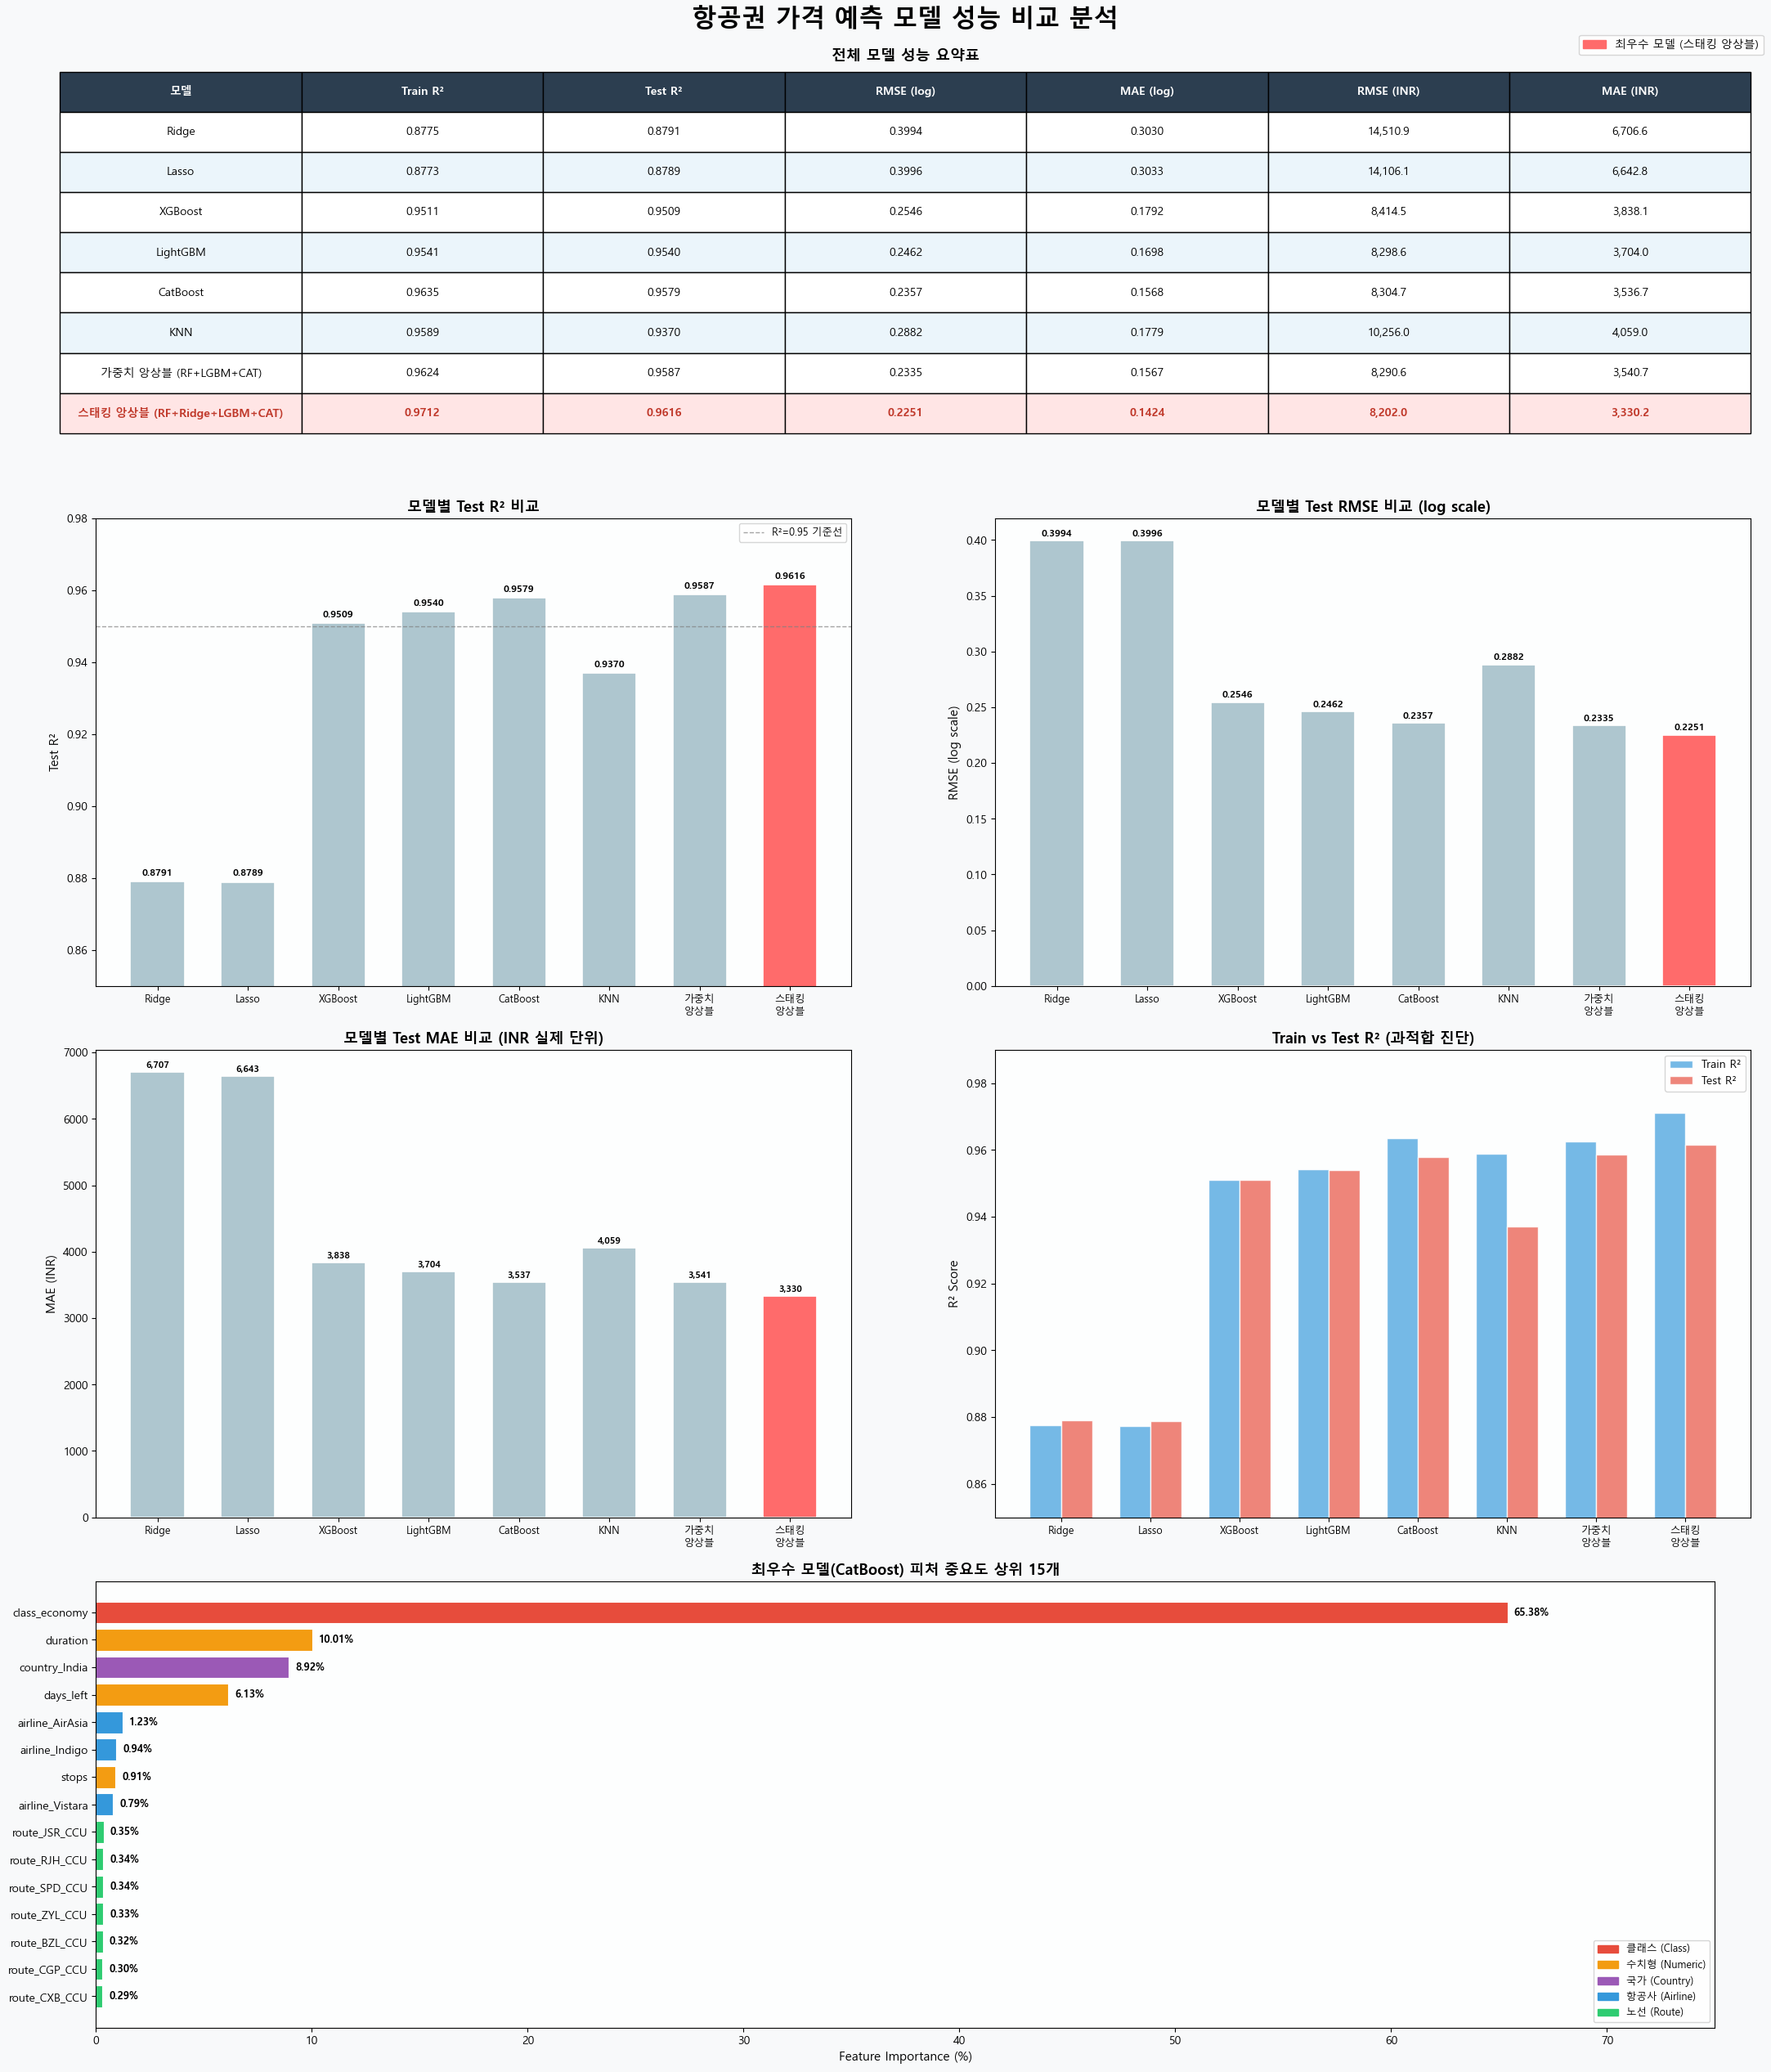

시각화 완료!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import rcParams

# 한글 폰트 설정
rcParams['font.family'] = 'Malgun Gothic'
rcParams['axes.unicode_minus'] = False

# ==========================================
# 1. 모델 성능 결과 데이터 (하드코딩)
# ==========================================
results = {
    'Model': [
        'Ridge', 'Lasso', 'XGBoost', 'LightGBM',
        'CatBoost', 'KNN', '가중치 앙상블\n(RF+LGBM+CAT)', '스태킹 앙상블\n(RF+Ridge+LGBM+CAT)'
    ],
    'Train R²':  [0.8775, 0.8773, 0.9511, 0.9541, 0.9635, 0.9589, 0.9624, 0.9712],
    'Test R²':   [0.8791, 0.8789, 0.9509, 0.9540, 0.9579, 0.9370, 0.9587, 0.9616],
    'Test RMSE (log)': [0.3994, 0.3996, 0.2546, 0.2462, 0.2357, 0.2882, 0.2335, 0.2251],
    'Test MAE (log)':  [0.3030, 0.3033, 0.1792, 0.1698, 0.1568, 0.1779, 0.1567, 0.1424],
    'Test RMSE (INR)': [14510.9, 14106.1, 8414.5, 8298.6, 8304.7, 10256.0, 8290.6, 8202.0],
    'Test MAE (INR)':  [6706.6,  6642.8,  3838.1, 3704.0, 3536.7, 4059.0,  3540.7, 3330.2],
}

df_results = pd.DataFrame(results)

# 색상 설정 (스태킹 앙상블 강조)
colors = ['#AEC6CF'] * 7 + ['#FF6B6B']

fig = plt.figure(figsize=(22, 26))
fig.patch.set_facecolor('#F8F9FA')

# 타이틀
fig.suptitle('항공권 가격 예측 모델 성능 비교 분석', fontsize=22, fontweight='bold', y=0.98)

# ==========================================
# 2. 성능 요약 표
# ==========================================
ax_table = fig.add_axes([0.03, 0.78, 0.94, 0.17])
ax_table.axis('off')

table_data = []
for _, row in df_results.iterrows():
    table_data.append([
        row['Model'].replace('\n', ' '),
        f"{row['Train R²']:.4f}",
        f"{row['Test R²']:.4f}",
        f"{row['Test RMSE (log)']:.4f}",
        f"{row['Test MAE (log)']:.4f}",
        f"{row['Test RMSE (INR)']:,.1f}",
        f"{row['Test MAE (INR)']:,.1f}",
    ])

col_labels = ['모델', 'Train R²', 'Test R²', 'RMSE (log)', 'MAE (log)', 'RMSE (INR)', 'MAE (INR)']

table = ax_table.table(
    cellText=table_data,
    colLabels=col_labels,
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1]
)
table.auto_set_font_size(False)
table.set_fontsize(10)

# 헤더 스타일
for j in range(len(col_labels)):
    table[0, j].set_facecolor('#2C3E50')
    table[0, j].set_text_props(color='white', fontweight='bold')

# 행 색상
for i in range(1, len(table_data) + 1):
    for j in range(len(col_labels)):
        if i == len(table_data):  # 마지막 행 (스태킹) 강조
            table[i, j].set_facecolor('#FFE5E5')
            table[i, j].set_text_props(fontweight='bold', color='#C0392B')
        elif i % 2 == 0:
            table[i, j].set_facecolor('#EBF5FB')
        else:
            table[i, j].set_facecolor('white')

ax_table.set_title('전체 모델 성능 요약표', fontsize=13, fontweight='bold', pad=10)

# ==========================================
# 3. Test R² 비교 막대그래프
# ==========================================
ax1 = fig.add_axes([0.05, 0.52, 0.42, 0.22])
ax1.set_facecolor('#FDFEFE')

short_names = ['Ridge', 'Lasso', 'XGBoost', 'LightGBM', 'CatBoost', 'KNN', '가중치\n앙상블', '스태킹\n앙상블']
bars = ax1.bar(short_names, df_results['Test R²'], color=colors, edgecolor='white', linewidth=1.2, width=0.6)

ax1.set_ylim(0.85, 0.98)
ax1.set_ylabel('Test R²', fontsize=11)
ax1.set_title('모델별 Test R² 비교', fontsize=13, fontweight='bold')
ax1.axhline(y=0.95, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='R²=0.95 기준선')
ax1.legend(fontsize=9)
ax1.tick_params(axis='x', labelsize=9)

for bar, val in zip(bars, df_results['Test R²']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{val:.4f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

# ==========================================
# 4. Test RMSE (log) 비교
# ==========================================
ax2 = fig.add_axes([0.55, 0.52, 0.42, 0.22])
ax2.set_facecolor('#FDFEFE')

bars2 = ax2.bar(short_names, df_results['Test RMSE (log)'], color=colors, edgecolor='white', linewidth=1.2, width=0.6)
ax2.set_ylabel('RMSE (log scale)', fontsize=11)
ax2.set_title('모델별 Test RMSE 비교 (log scale)', fontsize=13, fontweight='bold')
ax2.tick_params(axis='x', labelsize=9)

for bar, val in zip(bars2, df_results['Test RMSE (log)']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{val:.4f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

# ==========================================
# 5. Test MAE (INR) 비교
# ==========================================
ax3 = fig.add_axes([0.05, 0.27, 0.42, 0.22])
ax3.set_facecolor('#FDFEFE')

bars3 = ax3.bar(short_names, df_results['Test MAE (INR)'], color=colors, edgecolor='white', linewidth=1.2, width=0.6)
ax3.set_ylabel('MAE (INR)', fontsize=11)
ax3.set_title('모델별 Test MAE 비교 (INR 실제 단위)', fontsize=13, fontweight='bold')
ax3.tick_params(axis='x', labelsize=9)

for bar, val in zip(bars3, df_results['Test MAE (INR)']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f'{val:,.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# ==========================================
# 6. Train vs Test R² 비교 (과적합 진단)
# ==========================================
ax4 = fig.add_axes([0.55, 0.27, 0.42, 0.22])
ax4.set_facecolor('#FDFEFE')

x = np.arange(len(short_names))
width = 0.35
ax4.bar(x - width/2, df_results['Train R²'], width, label='Train R²', color='#5DADE2', alpha=0.85, edgecolor='white')
ax4.bar(x + width/2, df_results['Test R²'],  width, label='Test R²',  color='#EC7063', alpha=0.85, edgecolor='white')

ax4.set_xticks(x)
ax4.set_xticklabels(short_names, fontsize=9)
ax4.set_ylim(0.85, 0.99)
ax4.set_ylabel('R² Score', fontsize=11)
ax4.set_title('Train vs Test R² (과적합 진단)', fontsize=13, fontweight='bold')
ax4.legend(fontsize=10)

# ==========================================
# 7. 최우수 모델 피처 중요도 (스태킹 기준 CatBoost)
# ==========================================
ax5 = fig.add_axes([0.05, 0.03, 0.9, 0.21])
ax5.set_facecolor('#FDFEFE')

features = [
    'class_economy', 'duration', 'country_India', 'days_left',
    'airline_AirAsia', 'airline_Indigo', 'stops', 'airline_Vistara',
    'route_JSR_CCU', 'route_RJH_CCU', 'route_SPD_CCU', 'route_ZYL_CCU',
    'route_BZL_CCU', 'route_CGP_CCU', 'route_CXB_CCU'
]
importances = [65.38, 10.01, 8.92, 6.13, 1.23, 0.94, 0.91, 0.79, 0.35, 0.34, 0.34, 0.33, 0.32, 0.30, 0.29]

# 카테고리별 색상
def get_color(f):
    if 'class' in f: return '#E74C3C'
    elif 'airline' in f: return '#3498DB'
    elif 'route' in f: return '#2ECC71'
    elif 'country' in f: return '#9B59B6'
    else: return '#F39C12'

feat_colors = [get_color(f) for f in features]

bars5 = ax5.barh(features[::-1], importances[::-1], color=feat_colors[::-1], edgecolor='white', linewidth=0.8)

for bar, val in zip(bars5, importances[::-1]):
    ax5.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}%', va='center', fontsize=9, fontweight='bold')

ax5.set_xlabel('Feature Importance (%)', fontsize=11)
ax5.set_title('최우수 모델(CatBoost) 피처 중요도 상위 15개', fontsize=13, fontweight='bold')
ax5.set_xlim(0, 75)

# 범례
legend_elements = [
    mpatches.Patch(color='#E74C3C', label='클래스 (Class)'),
    mpatches.Patch(color='#F39C12', label='수치형 (Numeric)'),
    mpatches.Patch(color='#9B59B6', label='국가 (Country)'),
    mpatches.Patch(color='#3498DB', label='항공사 (Airline)'),
    mpatches.Patch(color='#2ECC71', label='노선 (Route)'),
]
ax5.legend(handles=legend_elements, loc='lower right', fontsize=9)

# 강조 패치 (범례)
best_patch = mpatches.Patch(color='#FF6B6B', label='최우수 모델 (스태킹 앙상블)')
fig.legend(handles=[best_patch], loc='upper right', fontsize=10, bbox_to_anchor=(0.98, 0.97))

plt.savefig('/mnt/user-data/outputs/model_performance_visualization.png',
            dpi=150, bbox_inches='tight', facecolor='#F8F9FA')
plt.show()
print("시각화 완료!")